# K-Means Clustering of Chick Calls By Acoustic Features
K-Means clustering is an unsupervised machine learning technique to cluster cases into groups by their features. It's a method of partitional clustering, where every case must fit in one and only one group. In this project, individual chicken calls were clustered by the numerical features extracted from the audio. 

For this analysis, only chick calls were included (age 0-7 days).

Steps
1. Import and visualize data using a scatterplot
2. Drop metadata columns
3. Use StandardScaler to get all variables on the same scale
4. Use principal components analysis (PCA) to reduce the number of variables
4. Use Elbow method to determine best number of clusters
5. Use K-means clustering to fit cases into clusters and append to original data
6. Explore characterstics of the clusters and plot using a scatterplot
7. Export results

Author: K Rubio

Last modified: 31Jul26

Dataset Information

Data created by using voice activity detection (VAD) to separate out individual calls from larger recordings, then for each call, audio features were extracted including zero-crossing rate, MFCCs 0-9, spectral centroid and bandwidth, etc. Program: chicken_feature_extraction_semi_automated.ipynb

1095 rows (one row per individual chicken call of varying durations)

Dataset columns include:
metadata
1.	filename
2.	call_num
3.	start
4.	end
5.	sample_rate
6.	frame_length
7.	vad_energy_threshold_used
8.  age (0 = chick, 1 = adult)

audio features
1.	duration_ms
2.	time_to_next_call_ms
3.	min_freq
4.	max_freq
5.	max_energy_freq
6.	seg1_max_energy_freq
7.	seg2_max_energy_freq
8.	seg3_max_energy_freq
9.	freq_change
10.	slope
11.	zcr
12.	mfcc0_avg
13.	mfcc0_std
14.	mfcc0_min
15.	mfcc0_max
16.	mfcc1_avg
17.	mfcc1_std
18.	mfcc1_min
19.	mfcc1_max
20.	mfcc2_avg
21.	mfcc2_std
22.	mfcc2_min
23.	mfcc2_max
24.	mfcc3_avg
25.	mfcc3_std
26.	mfcc3_min
27.	mfcc3_max
28.	mfcc4_avg
29.	mfcc4_std
30.	mfcc4_min
31.	mfcc4_max
32.	mfcc5_avg
33.	mfcc5_std
34.	mfcc5_min
35.	mfcc5_max
36.	mfcc6_avg
37.	mfcc6_std
38.	mfcc6_min
39.	mfcc6_max
40.	mfcc7_avg
41.	mfcc7_std
42.	mfcc7_min
43.	mfcc7_max
44.	mfcc8_avg
45.	mfcc8_std
46.	mfcc8_min
47.	mfcc8_max
48.	mfcc9_avg
49.	mfcc9_std
50.	mfcc9_min
51.	mfcc9_max	
52.	spectral_centroid
53.	spectral_bandwidth


In [1]:
import matplotlib.pyplot as plt
from kneed import KneeLocator
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd
from scipy.stats import zscore
import seaborn as sns
from sklearn.model_selection import train_test_split
import os
import sys
from pathlib import Path
from datetime import date

In [2]:
# have to modify where notebook looks for imports so it looks in the project root, not the notebook folder
os.getcwd()
sys.path.append(str(Path().resolve().parent.parent))
print(sys.path)

['/Users/dontfreakout/.pyenv/versions/3.12.8/lib/python312.zip', '/Users/dontfreakout/.pyenv/versions/3.12.8/lib/python3.12', '/Users/dontfreakout/.pyenv/versions/3.12.8/lib/python3.12/lib-dynload', '', '/Users/dontfreakout/Documents/Education (reduced)/Computer_Science/ML_and_Data_Science/Audio Signal Processing/Completed Projects/2026_04_Audio_Signal_Analysis/audio-signal-analysis/.venv/lib/python3.12/site-packages', '/Users/dontfreakout/Documents/Education (reduced)/Computer_Science/ML_and_Data_Science/Audio Signal Processing/Completed Projects/2026_04_Audio_Signal_Analysis/audio-signal-analysis']


In [3]:
from utils.stats_utils import (
  print_mean_and_std_by_group
)

## Data Preparation

In [5]:
# import the data
filename = "chicken_call_audio_features_ready_for_clustering"
df = pd.read_csv(f"../../data/output/chickens/{filename}.csv")
df = df[df['age'] == 0]
df

,filename,age,call_num,start,end,duration_ms,time_to_next_call_ms,min_freq,max_freq,max_energy_freq,...,mfcc8_max,mfcc9_avg,mfcc9_std,mfcc9_min,mfcc9_max,spectral_centroid,spectral_bandwidth,sample_rate,frame_length,vad_energy_threshold_used
5,chicks_20250404_1_trills_3.wav,0,1,0.900,1.296,396,30.0,215.332031,5081.835938,3919.042969,...,53.091338,-0.028531,23.102831,-39.281308,46.032467,3714.658511,1563.703958,22050,512,0.001
6,chicks_20250404_1_trills_3.wav,0,2,1.326,1.424,98,276.0,3273.046875,5124.902344,4952.636719,...,38.686783,5.453015,21.192670,-30.597496,39.003709,3861.436985,1516.995612,22050,512,0.001
7,chicks_20250404_1_trills_3.wav,0,3,1.700,2.170,470,350.0,3273.046875,5167.968750,4737.304688,...,43.584533,1.114964,23.037195,-36.278681,56.464745,3919.065063,1480.286443,22050,512,0.001
8,chicks_20250404_1_trills_3.wav,0,4,2.520,2.890,370,56.0,3273.046875,4995.703125,4521.972656,...,42.577533,-5.721755,22.799067,-38.237862,59.536291,3867.987914,1442.750530,22050,512,0.001
9,chicks_20250404_1_trills_3.wav,0,5,2.946,3.044,98,NaN,3186.914063,5167.968750,3574.511719,...,23.515279,1.317581,21.152677,-42.851562,29.882024,3755.906472,1488.407374,22050,512,0.001
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1072,chicks_20250407_from_vid_isolation_calls.wav,0,14,4.184,4.348,164,126.0,2799.316406,4349.707031,3445.312500,...,33.635755,15.497684,22.155133,-21.424703,81.340965,3835.305901,1290.211263,22050,512,0.001
1073,chicks_20250407_from_vid_isolation_calls.wav,0,15,4.474,4.634,160,404.0,2842.382813,4177.441406,3273.046875,...,35.145364,7.970049,25.261942,-30.160075,55.680634,3850.802899,1222.734146,22050,512,0.001
1074,chicks_20250407_from_vid_isolation_calls.wav,0,16,5.038,5.186,148,778.0,2713.183594,4349.707031,3229.980469,...,25.491285,16.540650,22.361868,-19.197597,59.316606,3693.247769,1241.778349,22050,512,0.001
1075,chicks_20250407_from_vid_isolation_calls.wav,0,17,5.964,6.078,114,238.0,2713.183594,4306.640625,3962.109375,...,16.941560,9.372930,10.674658,-8.216077,35.381530,3660.441771,1676.819304,22050,512,0.001


In [6]:
print(f"Number of missing values in time_to_next_call: {df['time_to_next_call_ms'].isna().sum()}")

Number of missing values in time_to_next_call: 17


In [7]:
# Handle missing data in the "time_to_next_call" variable by replacing it with the mean from all rows
# that have the same filename
df["time_to_next_call_ms"] = (
    df["time_to_next_call_ms"]
      .fillna(
          df.groupby("filename")["time_to_next_call_ms"]
            .transform("mean")
      )
)
print(f"Number of missing values in time_to_next_call: {df['time_to_next_call_ms'].isna().sum()}")

Number of missing values in time_to_next_call: 2


In [8]:
# Since some calls were alone in their file, replace with overall mean
mean = df["time_to_next_call_ms"].mean()
df.fillna({"time_to_next_call_ms": mean}, inplace=True)
print(f"Number of missing values in time_to_next_call: {df['time_to_next_call_ms'].isna().sum()}")

Number of missing values in time_to_next_call: 0


In [9]:
cols_to_drop = ['filename', 'age', 'call_num', 'start', 'end', 'sample_rate', 'frame_length', 'vad_energy_threshold_used']
df2 = df.drop(cols_to_drop, axis=1, inplace=False)
df2

,duration_ms,time_to_next_call_ms,min_freq,max_freq,max_energy_freq,seg1_max_energy_freq,seg2_max_energy_freq,seg3_max_energy_freq,freq_change,slope,...,mfcc8_avg,mfcc8_std,mfcc8_min,mfcc8_max,mfcc9_avg,mfcc9_std,mfcc9_min,mfcc9_max,spectral_centroid,spectral_bandwidth
5,396,30.000000,215.332031,5081.835938,3919.042969,3919.042969,4780.371094,4995.703125,1076.660156,2718.838778,...,10.373996,23.689427,-53.427172,53.091338,-0.028531,23.102831,-39.281308,46.032467,3714.658511,1563.703958
6,98,276.000000,3273.046875,5124.902344,4952.636719,4952.636719,5038.769531,3402.246094,1636.523438,-15820.312500,...,7.330167,22.452519,-47.178293,38.686783,5.453015,21.192670,-30.597496,39.003709,3861.436985,1516.995612
7,470,350.000000,3273.046875,5167.968750,4737.304688,4737.304688,4995.703125,5081.835938,344.531250,733.045213,...,10.528021,20.569072,-43.908391,43.584533,1.114964,23.037195,-36.278681,56.464745,3919.065063,1480.286443
8,370,56.000000,3273.046875,4995.703125,4521.972656,4521.972656,4521.972656,4909.570313,387.597656,1047.561233,...,11.274730,20.867014,-36.782958,42.577533,-5.721755,22.799067,-38.237862,59.536291,3867.987914,1442.750530
9,98,149.272727,3186.914063,5167.968750,3574.511719,4694.238281,4952.636719,3402.246094,1550.390625,-13183.593750,...,0.546108,14.943769,-22.352067,23.515279,1.317581,21.152677,-42.851562,29.882024,3755.906472,1488.407374
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1072,164,126.000000,2799.316406,4349.707031,3445.312500,4177.441406,3445.312500,3100.781250,1076.660156,-6565.000953,...,-20.663741,36.527246,-62.795343,33.635755,15.497684,22.155133,-21.424703,81.340965,3835.305901,1290.211263
1073,160,404.000000,2842.382813,4177.441406,3273.046875,4134.375000,3273.046875,3229.980469,904.394531,-5652.465820,...,-14.985246,30.328617,-53.648826,35.145364,7.970049,25.261942,-30.160075,55.680634,3850.802899,1222.734146
1074,148,778.000000,2713.183594,4349.707031,3229.980469,4005.175781,3229.980469,3229.980469,775.195312,-5237.806166,...,-26.332461,28.625312,-55.353494,25.491285,16.540650,22.361868,-19.197597,59.316606,3693.247769,1241.778349
1075,114,238.000000,2713.183594,4306.640625,3962.109375,3962.109375,3100.781250,3057.714844,904.394531,-7933.285362,...,-21.385226,18.525017,-44.184050,16.941560,9.372930,10.674658,-8.216077,35.381530,3660.441771,1676.819304


In [10]:
scaler = StandardScaler()
X = scaler.fit_transform(df2)
X

array([[ 2.14869608, -0.8718856 , -2.38399399, ...,  0.28700627,
        -0.48184106, -0.03741727],
       [-0.37358227,  0.40197397,  0.29948847, ..., -0.21198501,
        -0.16518313, -0.18264021],
       [ 2.77503366,  0.7851675 ,  0.29948847, ...,  1.02762305,
        -0.04085708, -0.29677429],
       ...,
       [ 0.04961879,  3.00147604, -0.19185338, ...,  1.23008468,
        -0.52803232, -1.03833016],
       [-0.23815793,  0.20519892, -0.19185338, ..., -0.4691337 ,
        -0.59880754,  0.31427457],
       [-0.05194946,  0.0279186 , -0.15405786, ...,  0.82154494,
        -0.77619736, -1.20820095]])

## Principal Component Analysis

In [11]:
# Fit PCA without specifying the number of components, since this is unknown
pca = PCA()
X_pca = pca.fit_transform(X)

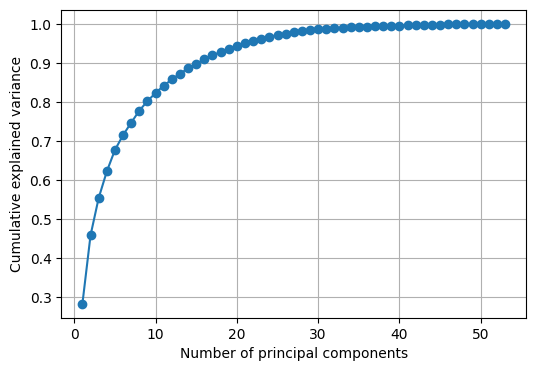

In [12]:
# Visualize how many components are needed to explain a certain % of variance in the dataset
plt.figure(figsize=(6,4))
plt.plot(
    range(1, len(pca.explained_variance_ratio_) + 1),
    pca.explained_variance_ratio_.cumsum(),
    marker="o"
)
plt.xlabel("Number of principal components")
plt.ylabel("Cumulative explained variance")
plt.grid(True)
plt.show()

In [17]:
# Keep enough components to explain about 85% of the variance. Should be around 12 based on the graph above
pca = PCA(n_components=0.85)
X_pca = pca.fit_transform(X)
print(pca.n_components_)

12


This means original 53 features were compressed into 12 principal components which is better due to the smaller sample size

## K-Means Clustering

<Axes: >

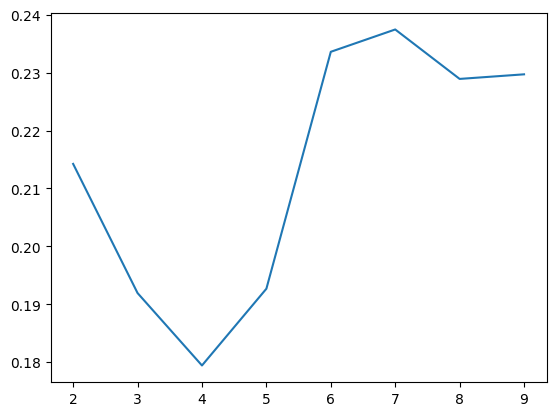

In [18]:
# Elbow method to determine best number of clusters
K = range(2, 10)
fits = []
score = []

for k in K:
    model = KMeans(n_clusters = k, random_state = 0, n_init='auto').fit(X_pca)
    fits.append(model)
    # Append the silhouette score to scores
    score.append(silhouette_score(X_pca, model.labels_, metric='euclidean'))
sns.lineplot(x = K, y = score)

Based on this graph, best to use 4 clusters

In [19]:
k = 4 # number of groups
kmeans = KMeans(n_clusters=k, random_state=0) # initialize kmeans algorithm
labels = kmeans.fit_predict(X_pca) # fit and predict to generate labels
df['cluster'] = labels # append those labels to the original df
df

,filename,age,call_num,start,end,duration_ms,time_to_next_call_ms,min_freq,max_freq,max_energy_freq,...,mfcc9_avg,mfcc9_std,mfcc9_min,mfcc9_max,spectral_centroid,spectral_bandwidth,sample_rate,frame_length,vad_energy_threshold_used,cluster
5,chicks_20250404_1_trills_3.wav,0,1,0.900,1.296,396,30.000000,215.332031,5081.835938,3919.042969,...,-0.028531,23.102831,-39.281308,46.032467,3714.658511,1563.703958,22050,512,0.001,3
6,chicks_20250404_1_trills_3.wav,0,2,1.326,1.424,98,276.000000,3273.046875,5124.902344,4952.636719,...,5.453015,21.192670,-30.597496,39.003709,3861.436985,1516.995612,22050,512,0.001,3
7,chicks_20250404_1_trills_3.wav,0,3,1.700,2.170,470,350.000000,3273.046875,5167.968750,4737.304688,...,1.114964,23.037195,-36.278681,56.464745,3919.065063,1480.286443,22050,512,0.001,3
8,chicks_20250404_1_trills_3.wav,0,4,2.520,2.890,370,56.000000,3273.046875,4995.703125,4521.972656,...,-5.721755,22.799067,-38.237862,59.536291,3867.987914,1442.750530,22050,512,0.001,3
9,chicks_20250404_1_trills_3.wav,0,5,2.946,3.044,98,149.272727,3186.914063,5167.968750,3574.511719,...,1.317581,21.152677,-42.851562,29.882024,3755.906472,1488.407374,22050,512,0.001,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1072,chicks_20250407_from_vid_isolation_calls.wav,0,14,4.184,4.348,164,126.000000,2799.316406,4349.707031,3445.312500,...,15.497684,22.155133,-21.424703,81.340965,3835.305901,1290.211263,22050,512,0.001,0
1073,chicks_20250407_from_vid_isolation_calls.wav,0,15,4.474,4.634,160,404.000000,2842.382813,4177.441406,3273.046875,...,7.970049,25.261942,-30.160075,55.680634,3850.802899,1222.734146,22050,512,0.001,0
1074,chicks_20250407_from_vid_isolation_calls.wav,0,16,5.038,5.186,148,778.000000,2713.183594,4349.707031,3229.980469,...,16.540650,22.361868,-19.197597,59.316606,3693.247769,1241.778349,22050,512,0.001,0
1075,chicks_20250407_from_vid_isolation_calls.wav,0,17,5.964,6.078,114,238.000000,2713.183594,4306.640625,3962.109375,...,9.372930,10.674658,-8.216077,35.381530,3660.441771,1676.819304,22050,512,0.001,1


## Analyzing clusters

In [20]:
# check how many calls are in each cluster
df['cluster'].value_counts()

cluster
2    82
0    78
1    59
3    57
Name: count, dtype: int64

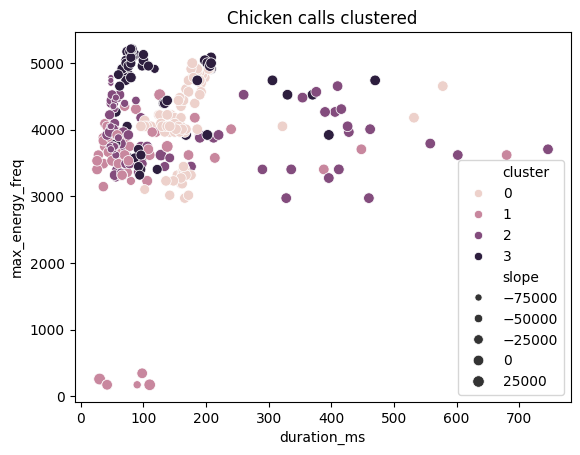

In [21]:
# Scatterplot using hue to highlight cluster with duration on the x-axis and max_energy_freq on the y-axis 
sns.scatterplot(
    data=df,
    x='duration_ms',
    y='max_energy_freq',
    hue='cluster',
    size='slope',
    # palette='tab10',
    # sizes=(20, 200),       # adjust dot size range
    # alpha=0.8
)

plt.title("Chicken calls clustered")
plt.show()

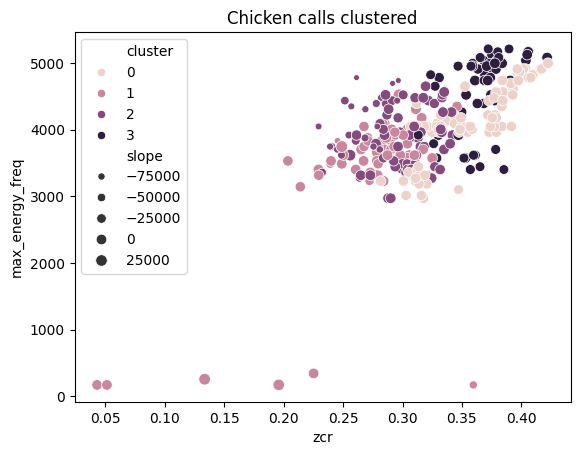

In [22]:
# Scatterplot using hue to highlight cluster with zero-crossing rate on the x-axis and max_energy_freq on the y-axis 
sns.scatterplot(
    data=df,
    x='zcr',
    y='max_energy_freq',
    hue='cluster',
    size='slope',
    # palette='tab10',
    # sizes=(20, 200),       # adjust dot size range
    # alpha=0.8
)

plt.title("Chicken calls clustered")
plt.show()

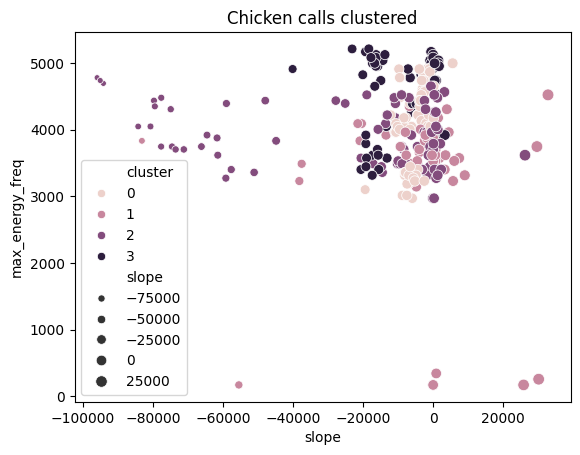

In [24]:
# Scatterplot using hue to highlight cluster with slope estimate on the x-axis and max_energy_freq on the y-axis 
sns.scatterplot(
    data=df,
    x='slope',
    y='max_energy_freq',
    hue='cluster',
    size='slope',
    # palette='tab10',
    # sizes=(20, 200),       # adjust dot size range
    # alpha=0.8
)

plt.title("Chicken calls clustered")
plt.show()

In [25]:
print_mean_and_std_by_group(df = df, groupby = "cluster", variable = "duration_ms", round = 1)

         duration_ms_mean  duration_ms_std
cluster                                   
1                    95.6            109.4
3                   128.9             90.6
2                   157.3            161.0
0                   171.2             70.0


In [28]:
print_mean_and_std_by_group(df = df, groupby = "cluster", variable = "max_energy_freq")

         max_energy_freq_mean  max_energy_freq_std
cluster                                           
1                    3375.968             1107.927
2                    3913.791              438.796
0                    4091.861              564.490
3                    4543.884              597.806


In [26]:
print_mean_and_std_by_group(df = df, groupby = "cluster", variable = "time_to_next_call_ms", round = 1)

         time_to_next_call_ms_mean  time_to_next_call_ms_std
cluster                                                     
1                            125.2                     141.1
3                            180.8                     221.0
2                            224.6                     230.3
0                            238.9                     143.7


In [27]:
print_mean_and_std_by_group(df = df, groupby = "cluster", variable = "zcr", round = 3)

         zcr_mean  zcr_std
cluster                   
1           0.269    0.056
2           0.294    0.028
0           0.354    0.036
3           0.365    0.022


In [29]:
print_mean_and_std_by_group(df = df, groupby = "cluster", variable = "spectral_bandwidth")

         spectral_bandwidth_mean  spectral_bandwidth_std
cluster                                                 
0                       1283.099                 156.578
3                       1627.457                 213.724
2                       1681.821                 238.323
1                       1765.216                 407.511


In [30]:
print_mean_and_std_by_group(df = df, groupby = "cluster", variable = "freq_change")

         freq_change_mean  freq_change_std
cluster                                   
1                 770.816         1206.753
0                 892.800          503.562
3                1001.861          798.536
2                1624.444         1549.567


In [31]:
print_mean_and_std_by_group(df = df, groupby = "cluster", variable = "slope")

         slope_mean  slope_std
cluster                       
2        -23482.510  31581.879
3         -9224.683   9542.187
0         -5076.544   4037.338
1         -3743.482  17594.354


Summary: Chicks show 4 call clusters

0 includes the longest calls (171 ms) that are medium frequency (4,092 Hz) and tend to be followed by longer silences with a narrow spectral bandwidth

1 includes very short calls (96 ms) that are lower frequency (3,376 Hz) but vary a lot in frequency, tend to be made in more rapid succession, lower in ZCR, and highest in spectral bandwidth but have lower change in frequency over the course of the call. 

2 includes medium-length calls (157 ms) that vary a lot in length, and are medium frequency (3,913 Hz) and have the highest frequency change over the course of the call.

3 includes medium-length calls (129 ms) that have the highest frequency (4,544 Hz) and highest ZCR

In [32]:
# Export results to csv
df.to_csv(f"../../data/output/chickens/{date.today()}_cluster_chicks_analysis_output.csv", header=True, index=False)